
Script générant un attaque adverse simple : rotation. On teste :

- Tous les angles pour toutes les images pour obtenir une accuracy moyenne du réseaux sur un data set en fonction de l'angle
- Tous les angle pour chaque image pour un label donné pour obtenir les angles maximisant ou minimisant la prediction d'un réseau sur ce label


> ... TODO ... # TODO test with rotation augmentation during training


In [1]:
from retinotopy import *
welcome()

Running on GPU :  NVIDIA GeForce RTX 3060 #GPU= 1
---------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host DESKTOP-27VNO0E with device cuda, pytorch==2.2.0+cu121
---------------------------------------------------------------------------------------------------
Welcome on Linux-5.10.16.3-microsoft-standard-WSL2-x86_64-with-glibc2.35
Random seed 1998 has been set.


# testing each network for different rotations

In [ ]:
# TODO verify raw n'est pas vraiment un dataset
for data_set_type in ['full', 'bbox', 'raw']:
    print(50*'=')
    print(f'{data_set_type=}')
    args = Params()
    args.angles = np.linspace(-180, 180, 101, dtype=int)
    args.do_rotation = True
    args.do_mask = args.do_mask if data_set_type != 'raw' else False
    data_set_type_test = data_set_type if data_set_type != 'raw' else 'full'
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type_test}' # Directory containing images
    args.folders = ['val'] # type of images to use
    print(50*'-')
     
    for model_name in  ['resnet18', 'resnet50', 'resnet101'] :
        print(f'{model_name=}')

        for do_polar in [False, True]:
            do_polar = do_polar if data_set_type != 'raw' else False
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            attack_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_attack_rotations.parquet'
            if os.path.isfile(attack_filename):
                df_angle = pd.read_parquet(attack_filename)
            else:
                print(args)
                df_mean, df_attack = None, None
                print(f'Computing {attack_filename}')

                image_dataset = image_datasets_transforms(args)['val']

                model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt' if data_set_type != 'raw' else None


                print(f"Loading pre-trained resnet {model_filename}")
                model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()
            
                pprint(f'Testing : {model_name}')

                torch.cuda.amp.GradScaler(enabled=True)
                model = model.eval()
                
                with torch.no_grad():
                    acc_angles =  torch.zeros(len(args.angles))
                    for i_image, (data, label) in tqdm(enumerate(image_dataset)) : 
                        label_batch = (torch.ones([len(data)])*label).data
                        
                        data = data.to(device)
                
                        outputs = model(data)
                
                        outputs = torch.softmax(outputs, dim=1)
                
                        prior_outputs = outputs[:,label]
                        argmax = torch.argmax(prior_outputs)
                        argmin = torch.argmin(prior_outputs)
                
                
                        _, preds = torch.max(outputs.data.cpu(), dim=1)
                        
                        df_attack_ = pd.DataFrame({'likelihood_0':[prior_outputs[len(args.angles)//2].item()], '0_pred':torch.argmax(outputs[len(args.angles)//2]).item(), 
                                            'likelihood_max':prior_outputs[argmax].item(), 'max_pos':args.angles[argmax.item()], 'max_pred':torch.argmax(outputs[argmax]).item(), 
                                            'likelihood_min':prior_outputs[argmin].item(), 'min_pos':args.angles[argmin.item()], 'min_pred':torch.argmax(outputs[argmin]).item(), 
                                            'i_image':i_image, 'filename':image_dataset.imgs[i_image][0], 'label':label})
                        
                        df_attack = store_pandas(df_attack, df_attack_)
                
                    #acc_angles /= len(image_dataset)
                    #df_mean_ = pd.DataFrame({'mean_accuracy':[acc_angles.numpy()], 'var':[args.angles]})
                    #df_mean = store_pandas(df_mean, df_mean_)
                    model.cpu()
                    #df_mean.to_parquet(df_filename_acc)
                    df_attack.to_parquet(attack_filename)

In [ ]:
print('good_2_go_real')
#Old script with smooth curves
angle_temp = args.angles
delta_angle = angle_temp[1] - angle_temp[0]
angles_min = angle_temp - delta_angle/2
angles_max = angle_temp + delta_angle/2

# Loading and testing the networks
for data_set_type in ['raw', 'full', 'bbox']:
    
    print(50*'=')
    data_set_type_test = data_set_type if data_set_type != 'raw' else 'full'
    print(f'{data_set_type=}')
    args = Params()
    #args.do_rotation = True
    args.do_mask = args.do_mask if data_set_type != 'raw' else False
    args.do_rot_train = True # TODO check this with respect to image_datasets_transforms
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type_test}' # Directory containing images
    args.folders = ['val'] # type of images to use
    print(50*'-')
        
    for model_name in  ['resnet18', 'resnet50', 'resnet101']: 
        print(f'{model_name=}')

        for do_polar in [True, False]:
            do_polar = do_polar if data_set_type != 'raw' else False
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            df_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_rotations_accuracy_smooth.parquet'
            if os.path.isfile(df_filename):
                df_angle = pd.read_parquet(df_filename)
            else:
                print(f'Computing {df_filename}')
                results = np.zeros((0, 3))
                #model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt'
                model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt' if data_set_type != 'raw' else None

                #if os.path.isfile(model_filename):
                print(f"Loading pre-trained resnet {model_filename}")
                model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()

                for angle, angle_min, angle_max in zip(angle_temp, angles_min, angles_max):
                    print(f'{angle=}', end='')
                    args.angles = [angle_min, angle_max]
                    dataloaders = datasets_transforms(args, shuffle=False, verbose=False)
                    
                    with torch.no_grad():
                        for i_image, (images, labels) in enumerate(dataloaders['val']):
                            images, labels = images.to(device), labels.to(device)

                            outputs = model(images)

                            _, preds = torch.max(outputs.data, dim=1)
                            detect = (preds == labels.data).cpu().numpy()

                            results_ = np.vstack([i_image*args.batch_size_val + np.arange(len(detect)), angle*np.ones(len(detect)), detect]).T
                            results = np.vstack((results, results_))

                            
                    print(f', Accuracy={detect.mean():.3f}')
                df_angle = pd.DataFrame(results, columns=['i_image', 'angle', 'match'])     
                df_angle.to_parquet(df_filename)                        
                print(25*'. ')

    print(50*'=')

In [ ]:
skuuuu

model_name='resnet18'
data_set_type='full'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='raw'
--------------------------------------------------


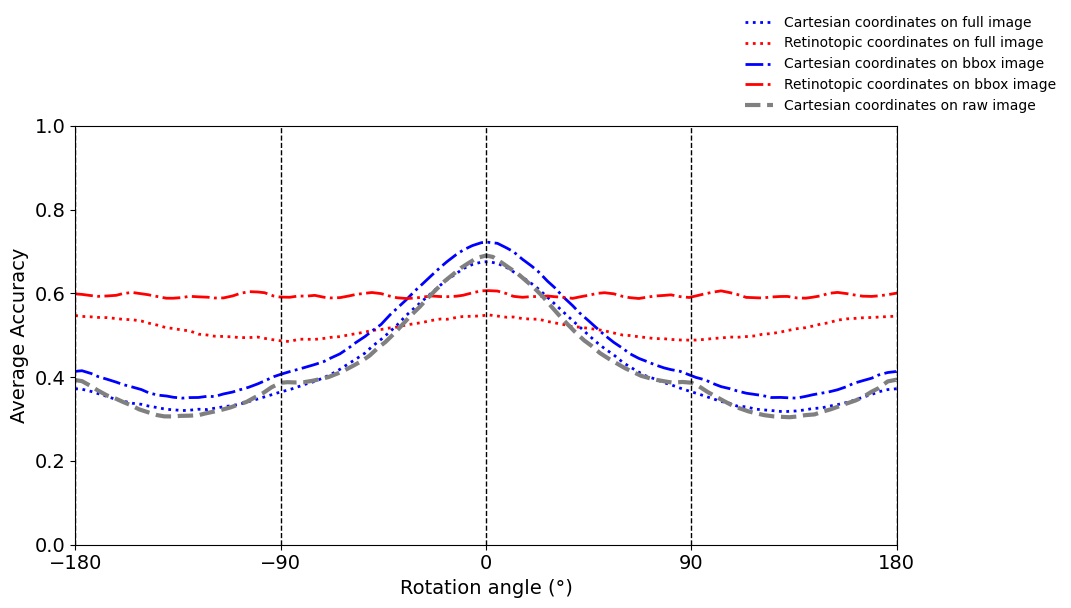

model_name='resnet50'
data_set_type='full'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='raw'
--------------------------------------------------


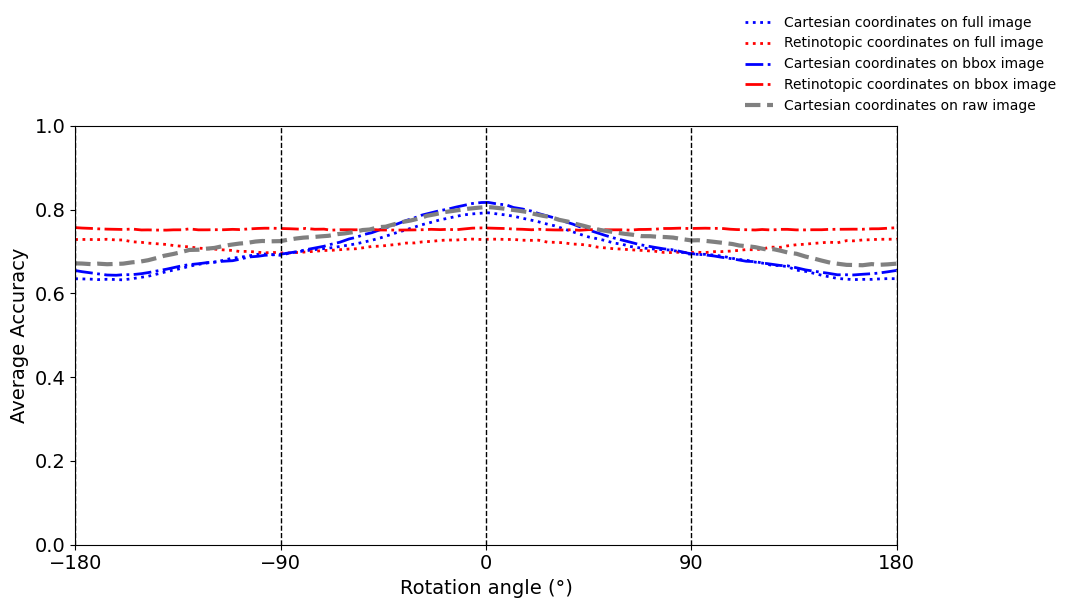

model_name='resnet101'
data_set_type='full'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='raw'
--------------------------------------------------


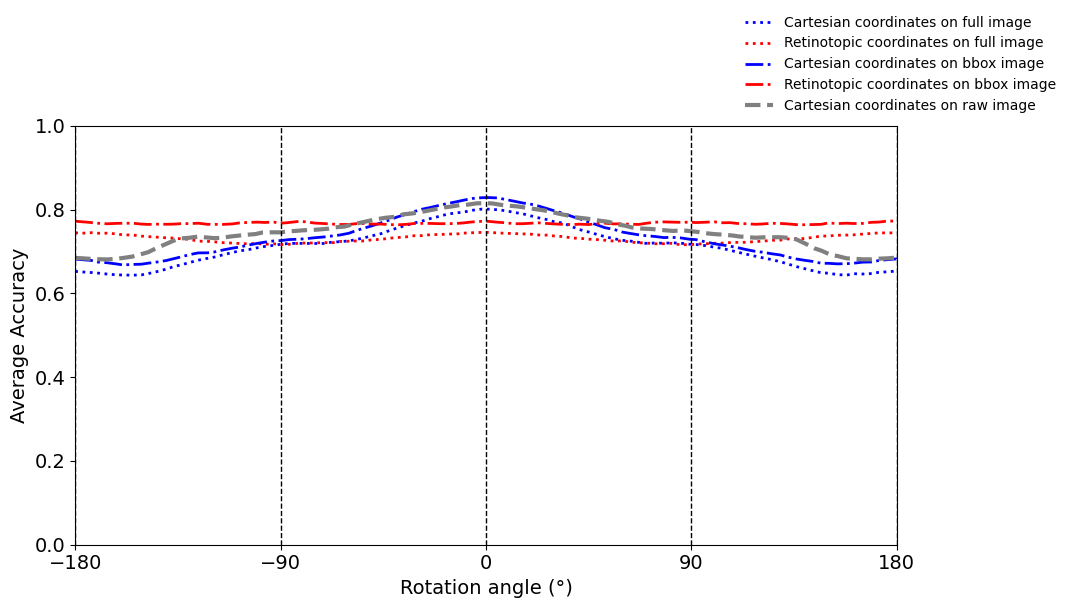

In [3]:
for model_name in  ['resnet18', 'resnet50', 'resnet101', ]:
    print(50*'=')
    print(f'{model_name=}')
    fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))
    for data_set_type, ls in zip(['full', 'bbox', 'raw'], data_set_linestyles):
        print(f'{data_set_type=}')
        print(50*'-')

        for do_polar, color in zip([False, True], ['b', 'r']):

            if data_set_type == 'raw' :
                df_filename_acc = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_rotations_accuracy_smooth.parquet' if not do_polar else 'None'
                color = 'grey'
                lw = 3
                ls = '--'
            else:
                lw = 2
                df_filename_acc = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_rotations_accuracy_smooth.parquet'
            

            if os.path.isfile(df_filename_acc):
                df_angle = pd.read_parquet(df_filename_acc)

                results = [df_angle[df_angle['angle'] == angle]['match'].mean() for angle in np.hstack((df_angle['angle'].unique(), -180.))]
                label = 'Retinotopic mapping' if do_polar else 'Cartesian mapping'
                label += f' on {data_set_type} image' 
                ax.plot(np.hstack((df_angle['angle'].unique(), 180)), results, color=color, ls=ls, lw=lw, label=label)
        
    #ax.hlines(xmin=-185, xmax=185, y=1/2, ls='--', ec='gray')
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xlim(-180, 180)
    ax.set_ylim(0, 1)

    for angle in [-180, -90, 0, 90, 180]:
        ax.axvline(x=angle, c='k', ls='--', lw=1)
    ax.set_xticks([-180, -90, 0, 90, 180])
    #ax.set_yscale("logit", use_overline=True) #one_half="1/2", 
    #ax.set_yticks([.7, .75, .8])
    ax.set_ylabel('Average Accuracy', font=font)
    ax.set_xlabel('Rotation angle (°)', font=font)
    plt.legend(bbox_to_anchor=(0.8, 1), loc='best', fontsize=10, edgecolor='none')
    plt.tight_layout()
    # plt.xticks(font=font)
    # plt.yticks(font=font);
    plt.show()

In [4]:
df_angle

,i_image,angle,match
0,0.0,-180.0,1.0
1,1.0,-180.0,1.0
2,2.0,-180.0,0.0
3,3.0,-180.0,1.0
4,4.0,-180.0,1.0
...,...,...,...
5049995,49995.0,180.0,0.0
5049996,49996.0,180.0,1.0
5049997,49997.0,180.0,0.0
5049998,49998.0,180.0,0.0


# analysis: average accuracy for different rotations

In [5]:
#Rotation attack read out
acc_plot = {}
for model_name in  ['resnet18', 'resnet50', 'resnet101']:

    print(50*'=')
    print(f'{model_name=}')
    for data_set_type, ls in zip(data_set_types, data_set_linestyles):
        print(f'{data_set_type=}')
        print(50*'-')

        for do_polar, color in zip([True, False], ['b', 'r']):

            df_filename_acc = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_attack_rotations.parquet'
            

            if os.path.isfile(df_filename_acc):

                df_angle = pd.read_parquet(df_filename_acc)
                print(do_polar)
                min = accuracy_score(df_angle['min_pred'], df_angle["label"])
                print(min, 'min')
                zero = accuracy_score(df_angle['0_pred'], df_angle["label"])
                print(zero, 'zero')
                max = accuracy_score(df_angle['max_pred'], df_angle["label"])
                print(max, 'max')
                print(zero-min, 'delta1', max-zero, 'delta2')

                acc_plot[get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_min'] = min

                acc_plot[get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_zero'] = zero

model_name='resnet18'
data_set_type='raw'
--------------------------------------------------
False
0.09872 min
0.69226 zero
0.84404 max
0.59354 delta1 0.15178000000000003 delta2
data_set_type='full'
--------------------------------------------------
True
0.21468 min
0.54784 zero
0.75382 max
0.33316 delta1 0.20598000000000005 delta2
False
0.09144 min
0.67824 zero
0.84908 max
0.5868 delta1 0.17084 delta2
data_set_type='bbox'
--------------------------------------------------
True
0.33612 min
0.61252 zero
0.77426 max
0.2764 delta1 0.16174 delta2
False
0.09912 min
0.72546 zero
0.88014 max
0.62634 delta1 0.15468000000000004 delta2
model_name='resnet50'
data_set_type='raw'
--------------------------------------------------
False
0.43548 min
0.8072 zero
0.9001 max
0.37172000000000005 delta1 0.09289999999999998 delta2
data_set_type='full'
--------------------------------------------------
True
0.43386 min
0.72892 zero
0.87612 max
0.29506 delta1 0.1472 delta2
False
0.36246 min
0.79478 zero
0.90

In [6]:
df_angle

,likelihood_0,0_pred,likelihood_max,max_pos,max_pred,likelihood_min,min_pos,min_pred,i_image,filename,label
0,0.347551,394,0.993246,115,0,0.064111,-26,394,0,/data/JNJER/Deep_learning/data/Imagenet_bbox/v...,0
1,0.991035,0,0.998840,-62,0,0.321447,172,391,1,/data/JNJER/Deep_learning/data/Imagenet_bbox/v...,0
2,0.981371,0,0.995826,176,0,0.007936,79,329,2,/data/JNJER/Deep_learning/data/Imagenet_bbox/v...,0
3,0.998440,0,0.999693,-58,0,0.976491,72,0,3,/data/JNJER/Deep_learning/data/Imagenet_bbox/v...,0
4,0.999422,0,0.999827,86,0,0.997067,90,0,4,/data/JNJER/Deep_learning/data/Imagenet_bbox/v...,0
...,...,...,...,...,...,...,...,...,...,...,...
49995,0.958478,999,0.999307,108,999,0.041057,158,619,49995,/data/JNJER/Deep_learning/data/Imagenet_bbox/v...,999
49996,0.865796,999,0.872298,10,999,0.005212,122,419,49996,/data/JNJER/Deep_learning/data/Imagenet_bbox/v...,999
49997,0.987980,999,0.987980,0,999,0.000320,162,885,49997,/data/JNJER/Deep_learning/data/Imagenet_bbox/v...,999
49998,0.060442,333,0.174540,64,333,0.003385,-137,333,49998,/data/JNJER/Deep_learning/data/Imagenet_bbox/v...,999


In [7]:
fig_width = 15
fontsize = 18
font = font_manager.FontProperties(weight='normal', size=fontsize)
dpi = 'figure'
dpi = 200
opts_savefig = dict(dpi=dpi, bbox_inches='tight', pad_inches=0, edgecolor=None)

colors = ['b', 'r', 'k', 'g', 'm', 'y']
fig_width = 20
phi = (np.sqrt(5)+1)/2 # golden ratio for the figures :-)

data_set_type='full'
model_name='resnet101'
--------------------------------------------------
data_set_type='bbox'
model_name='resnet101'
--------------------------------------------------
data_set_type='raw'
model_name='resnet101'
--------------------------------------------------


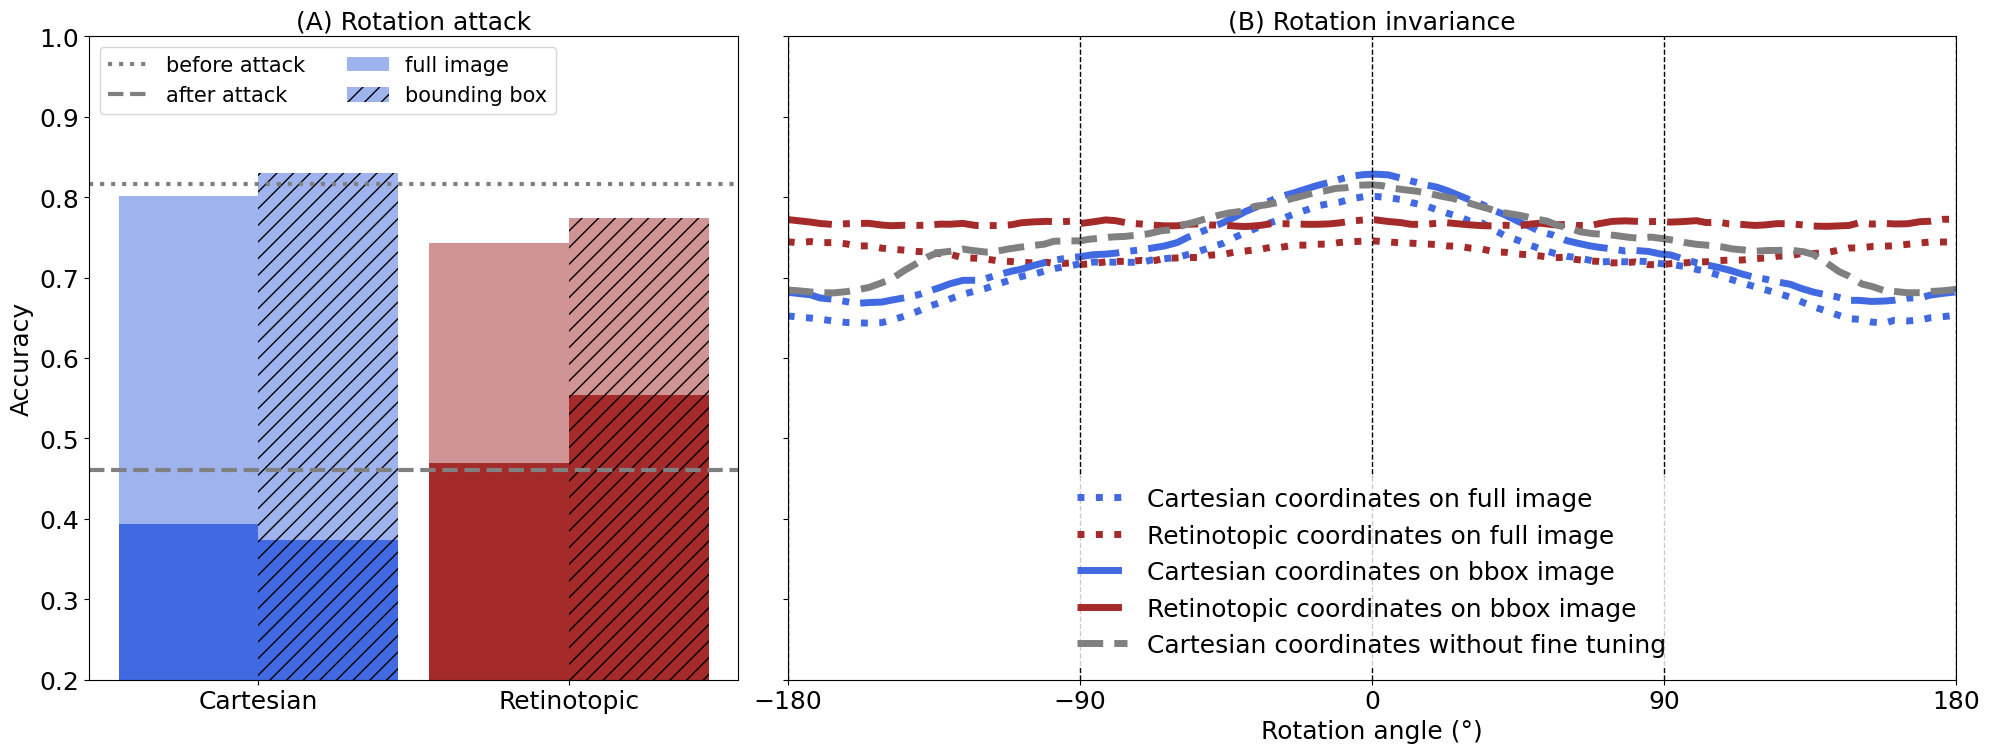

In [10]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
fig, axs = plt.subplots(1, 2, sharex=False, sharey=True, figsize=(fig_width, fig_width/2.61803), width_ratios=[1, 1.8])

titles = ["(A) Rotation attack", "(B) Rotation invariance"]

#colors_cart = ['lightsteelblue', 'brown']
colors = ['royalblue', 'brown']
acc_full_ret_min = acc_plot[get_filename(data_cache, datetag, 'full', model_name, True) + '_min']

acc_full_ret = acc_plot[get_filename(data_cache, datetag, 'full', model_name, True) + '_zero']

acc_full_lin_min = acc_plot[get_filename(data_cache, datetag, 'full', model_name, False) + '_min']

acc_full_lin = acc_plot[get_filename(data_cache, datetag, 'full', model_name, False) + '_zero']

acc_bbox_ret_min = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, True) + '_min']

acc_bbox_ret = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, True) + '_zero']

acc_bbox_lin_min = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, False) + '_min']

acc_bbox_lin = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, False) + '_zero']


type_mod = ( "Cartesian", "Retinotopic")
data_means = {
    'full image': (acc_full_lin, acc_full_ret),
    'bounding box': (acc_bbox_lin, acc_bbox_ret ),

}

x = np.arange(len(type_mod))  # the label locations
width = 0.45  # the width of the bars
multiplier = 0
hatchs = [None, "//"]

for i, (attribute, measurement) in enumerate(data_means.items()):
    offset = width * multiplier
    rects = axs[0].bar(x + offset, measurement, width, label=attribute, alpha =.5, color = colors, hatch=hatchs[i])
    #axs[0].bar_label(rects, padding=2)
    multiplier += 1

data_means = {
    'full image': (acc_full_lin_min, acc_full_ret_min),
    'bounding box': (acc_bbox_lin_min, acc_bbox_ret_min )
}
multiplier = 0

for i, (attribute, measurement) in enumerate(data_means.items()):
    offset = width * multiplier
    rects = axs[0].bar(x + offset, measurement, width, color = colors, hatch=hatchs[i])
    #axs[0].bar_label(rects, padding=2)
    multiplier += 1


axs[0].axhline(y=0.817, c='gray', ls='dotted', lw=3, label='before attack')
axs[0].axhline(y=0.461, c='gray', ls='--', lw=3, label='after attack')

axs[0].set_xticks(x + width/2, type_mod)
axs[0].set_ylabel('Accuracy', font=font)
axs[0].legend(loc='upper left', ncols=2, fontsize=15)
axs[0].set_ylim(0.2, 1)


for data_set_type, ls in zip(['full', 'bbox', 'raw'], data_set_linestyles):
    print(f'{data_set_type=}')
    for model_name in  ['resnet101']:
        print(50*'=')
        print(f'{model_name=}')

        print(50*'-')

        for do_polar, color in zip([False, True],  ['royalblue', 'brown', 'gray']):

            if data_set_type == 'raw' :
                df_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_rotations_accuracy_smooth.parquet' if not do_polar else 'None'
                color = 'grey'
                lw = 3
                ls = '--'
            else:
                lw = 2
                df_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_rotations_accuracy_smooth.parquet'

            if os.path.isfile(df_filename):
               # data_set_type = 'full image' if 'full' in data_set_type else 'bounding box'
                
                df_angle = pd.read_parquet(df_filename)

                results = [df_angle[df_angle['angle'] == angle]['match'].mean() for angle in np.hstack((df_angle['angle'].unique(), -180.))]
                label = 'Retinotopic coordinates' if do_polar else 'Cartesian coordinates'
                label += f' on {data_set_type} image' if data_set_type != 'raw' else f' without fine tuning'
                axs[1].plot(np.hstack((df_angle['angle'].unique(), 180)), results, color=color, ls=ls, lw=5, label=label)
        

ax = axs[1]
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_xlim(-180, 180)


for angle in [-180, -90, 0, 90, 180]:
    ax.axvline(x=angle, c='k', ls='--', lw=1)
ax.set_xticks([-180, -90, 0, 90, 180])
#ax.set_yscale("logit", use_overline=True) #one_half="1/2", 
#ax.set_yticks([.7, .75, .8])
#ax.set_ylabel('Average Accuracy', font=font)
ax.set_xlabel('Rotation angle (°)', font=font)
plt.legend(loc='lower center', fontsize=fontsize, edgecolor='none')
plt.tight_layout()
# plt.xticks(font=font)
# plt.yticks(font=font);


# https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
for j, ax in enumerate(axs):
        ax.set_title(titles[j], font=font)
        ax.tick_params(axis='both', labelsize=fontsize)    
        #for i, container in enumerate(ax.containers):
        #    ax.bar_label(container, padding=-15, color='black', fmt='%.3f', rotation=0, label_type = 'edge', fontsize=fontsize, weight='bold')

plt.xticks(font=font)
plt.yticks(font=font)
plt.tight_layout()

In [11]:
to_save(fig, name='fig-rotation')

data_set_type='bbox'
model_name='resnet101'
--------------------------------------------------


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(76.30838795138011, 0.5, 'Accuracy')

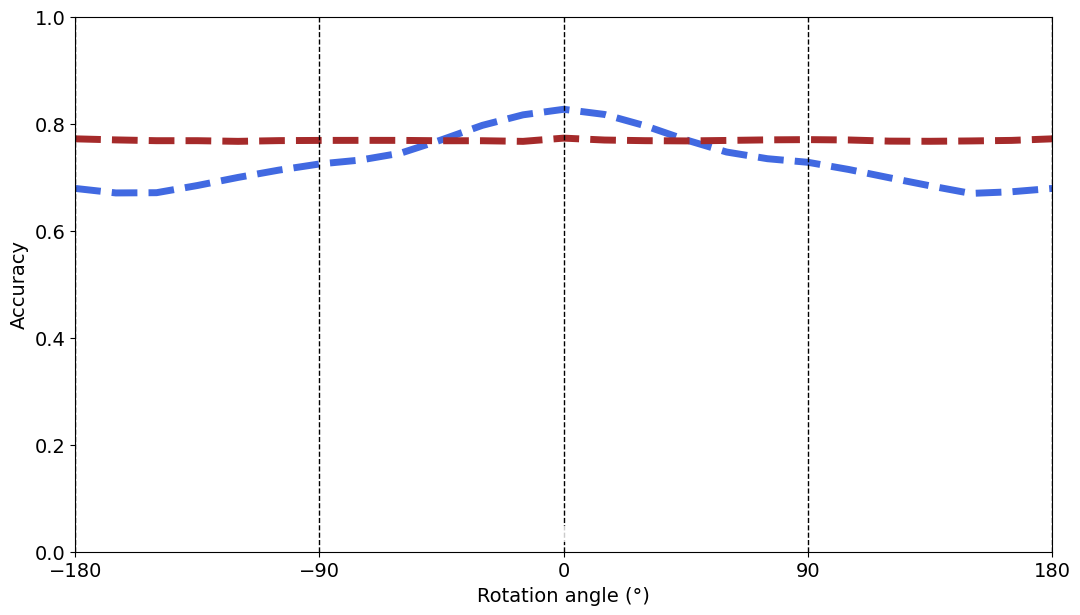

In [2]:
fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))
for data_set_type, ls in zip(['bbox'], data_set_linestyles):
    print(f'{data_set_type=}')
    for model_name in  ['resnet101']:
        print(50*'=')
        print(f'{model_name=}')

        print(50*'-')

        for do_polar, color in zip([False, True],  ['royalblue', 'brown']):

            df_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_test-rotations.json'

            if os.path.isfile(df_filename):
               # data_set_type = 'full image' if 'full' in data_set_type else 'bounding box'
                
                df_angle = pd.read_json(df_filename)

                results = [df_angle[df_angle['angle'] == angle]['match'].mean() for angle in np.hstack((df_angle['angle'].unique(), -180.))]
                label = 'Retinotopic coordinates' if do_polar else 'Cartesian coordinates'
                label += f' on {data_set_type} image' 
                ax.plot(np.hstack((df_angle['angle'].unique(), 180)), results, color=color, ls='--', lw=5)

ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_xlim(-180, 180)


for angle in [-180, -90, 0, 90, 180]:
    ax.axvline(x=angle, c='k', ls='--', lw=1)
ax.set_xticks([-180, -90, 0, 90, 180])
#ax.set_yscale("logit", use_overline=True) #one_half="1/2", 
#ax.set_yticks([.7, .75, .8])
#ax.set_ylabel('Average Accuracy', font=font)
ax.set_xlabel('Rotation angle (°)', font=font)
plt.legend(loc='lower center', fontsize=fontsize, edgecolor='none')
plt.tight_layout()
ax.set_ylim(0, 1)
#ax.set_xticks(x + width/2, type_mod)
ax.set_ylabel('Accuracy', font=font)
# plt.xticks(font=font)
# plt.yticks(font=font);